# Sprint 2 Feature EDA

Exploratory analysis of the generated Sprint 2 feature parquet files.

## 1. Dataset summary

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

feature_paths = sorted(Path('data/features').glob('*_features.parquet'))
if not feature_paths:
    feature_paths = sorted(Path('../data/features').glob('*_features.parquet'))
assert feature_paths, 'No feature parquet files found under data/features/'
dfs = [pd.read_parquet(path) for path in feature_paths]
df = pd.concat(dfs, ignore_index=True)

excluded = {'commit_sha', 'test_id', 'label', 'timestamp', 'feature_source'}
numeric_cols = [col for col in df.select_dtypes(include='number').columns if col not in excluded]

print('Files loaded:')
for path in feature_paths:
    print('-', path.name)
print('Combined shape:', df.shape)
print('Feature count:', len(numeric_cols))
display(df['label'].value_counts().sort_index().rename(index={0: 'PASS/other', 1: 'FAIL'}).to_frame('rows'))

summary = df.groupby('repo').agg(
    rows=('label', 'size'),
    fail_count=('label', 'sum'),
    fail_rate=('label', 'mean'),
    feature_source_job_sequence=('feature_source', lambda s: (s == 'job_sequence').mean()),
    commit_meta_missing_rate=('commit_meta_missing', 'mean'),
    commit_diff_missing_rate=('commit_diff_missing', 'mean'),
).reset_index()
summary['feature_count'] = len(numeric_cols)
display(summary)

Files loaded:
- adamfisk@LittleProxy_features.parquet
- deeplearning4j@deeplearning4j_features.parquet
- l0rdn1kk0n@wicket-bootstrap_features.parquet
- neuland@jade4j_features.parquet
- thinkaurelius@titan_features.parquet
Combined shape: (160454, 37)
Feature count: 31


,rows
label,
PASS/other,146492
FAIL,13962


,repo,rows,fail_count,fail_rate,feature_source_job_sequence,commit_meta_missing_rate,commit_diff_missing_rate,feature_count
0,adamfisk@LittleProxy,15772,187,0.011856,0.304210,0.304210,1.000000,31
1,deeplearning4j@deeplearning4j,15509,932,0.060094,0.056999,0.056999,1.000000,31
2,l0rdn1kk0n@wicket-bootstrap,48228,10860,0.225180,0.193311,0.193311,1.000000,31
3,neuland@jade4j,35887,1323,0.036866,0.001003,0.001003,0.999025,31
4,thinkaurelius@titan,45058,660,0.014648,0.129056,0.129056,1.000000,31


## 2. Missing value heatmap

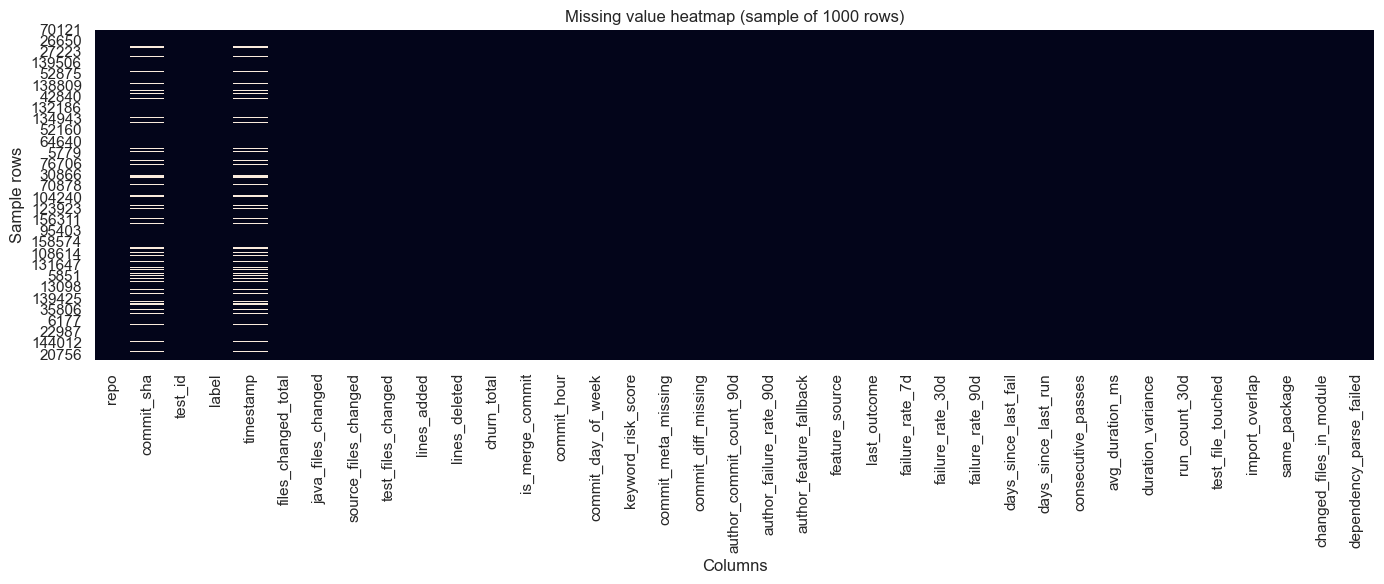

In [2]:
sample = df.sample(n=min(1000, len(df)), random_state=42)
plt.figure(figsize=(14, 6))
sns.heatmap(sample.isnull(), cbar=False)
plt.xlabel('Columns')
plt.ylabel('Sample rows')
plt.title('Missing value heatmap (sample of 1000 rows)')
plt.tight_layout()
plt.show()

## 3. Correlation with label

C:\Users\63200744\Desktop\FSB-Capstone\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\63200744\Desktop\FSB-Capstone\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,abs_corr_with_label
last_outcome,0.576132
failure_rate_90d,0.570321
failure_rate_30d,0.532725
failure_rate_7d,0.382167
consecutive_passes,0.267297
run_count_30d,0.119162
days_since_last_fail,0.117743
dependency_parse_failed,0.098356
author_failure_rate_90d,0.086800
avg_duration_ms,0.041260


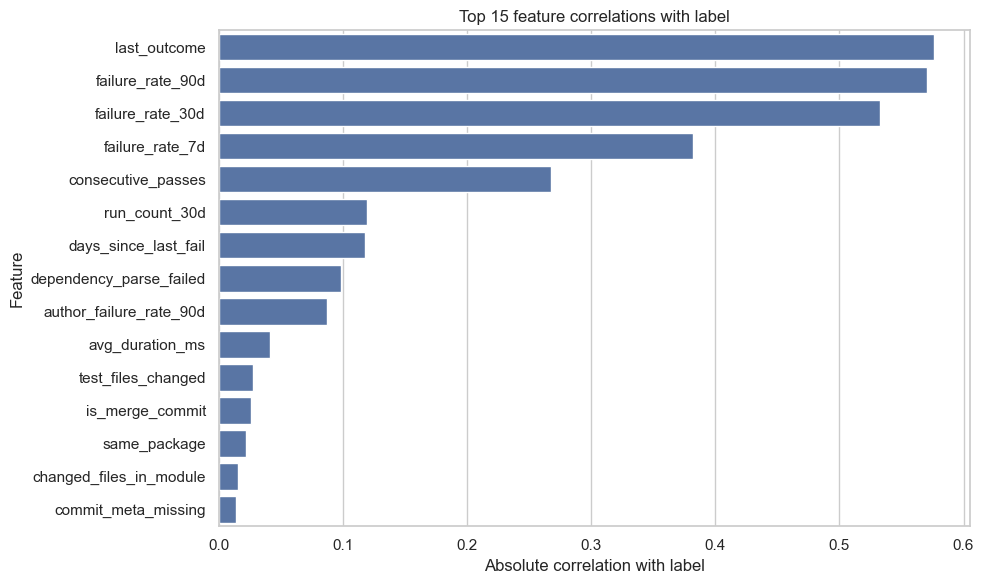

In [3]:
corr = df[numeric_cols].corrwith(df['label']).abs().sort_values(ascending=False)
top_corr = corr.head(15)
display(top_corr.to_frame('abs_corr_with_label'))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, orient='h')
plt.xlabel('Absolute correlation with label')
plt.ylabel('Feature')
plt.title('Top 15 feature correlations with label')
plt.tight_layout()
plt.show()

## 4. Mutual information ranking

,mutual_information
days_since_last_fail,0.236571
failure_rate_90d,0.201638
failure_rate_30d,0.188738
consecutive_passes,0.162253
failure_rate_7d,0.155859
days_since_last_run,0.140256
last_outcome,0.098896
author_failure_rate_90d,0.085438
avg_duration_ms,0.054852
commit_diff_missing,0.041086


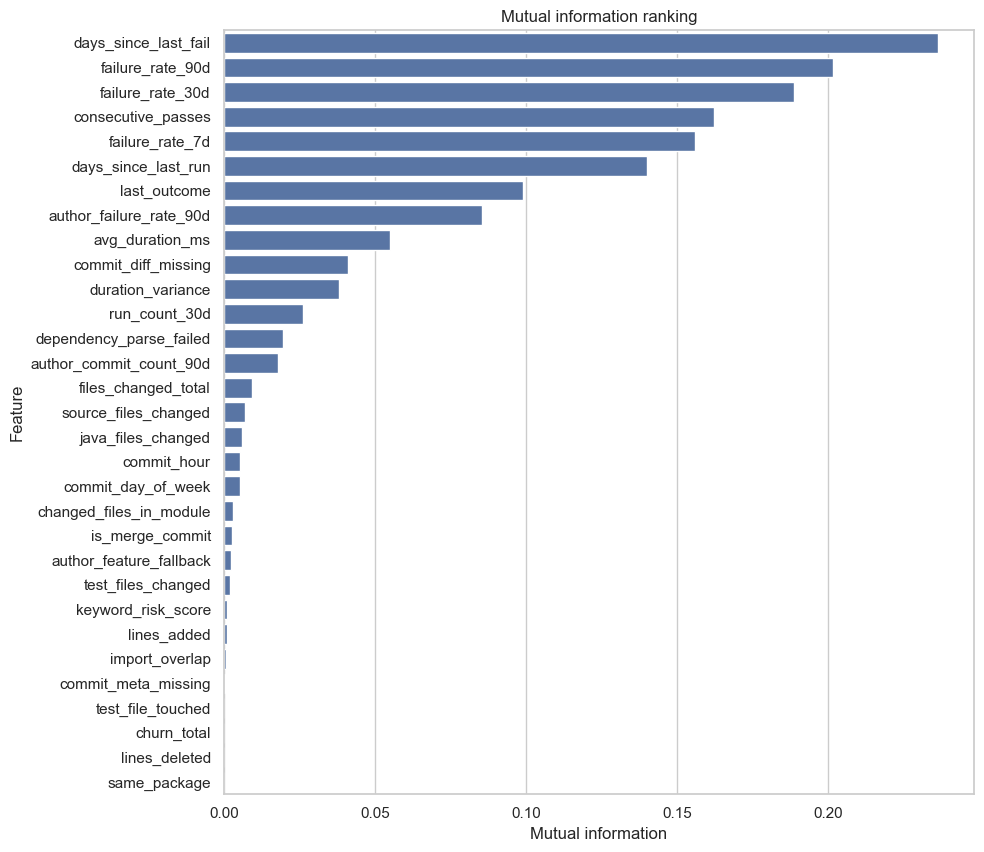

In [4]:
X = df[numeric_cols].fillna(0)
y = df['label'].astype(int)
mi = pd.Series(mutual_info_classif(X, y, random_state=42), index=numeric_cols).sort_values(ascending=False)
display(mi.to_frame('mutual_information'))

plt.figure(figsize=(10, max(7, 0.28 * len(mi))))
sns.barplot(x=mi.values, y=mi.index, orient='h')
plt.xlabel('Mutual information')
plt.ylabel('Feature')
plt.title('Mutual information ranking')
plt.tight_layout()
plt.show()

## 5. Distribution plots for top-5 MI features

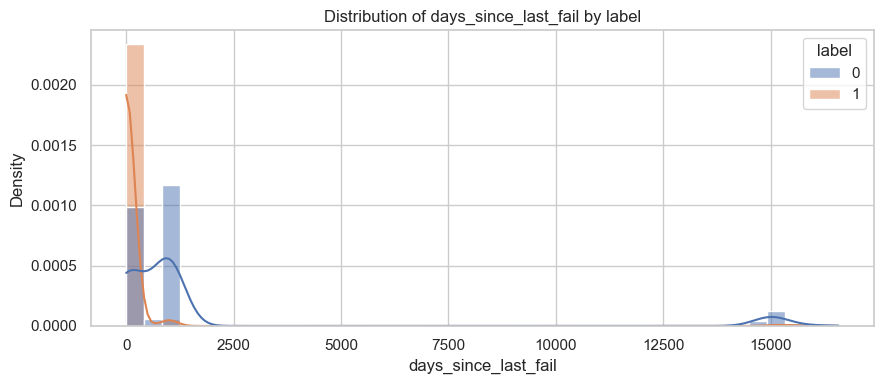

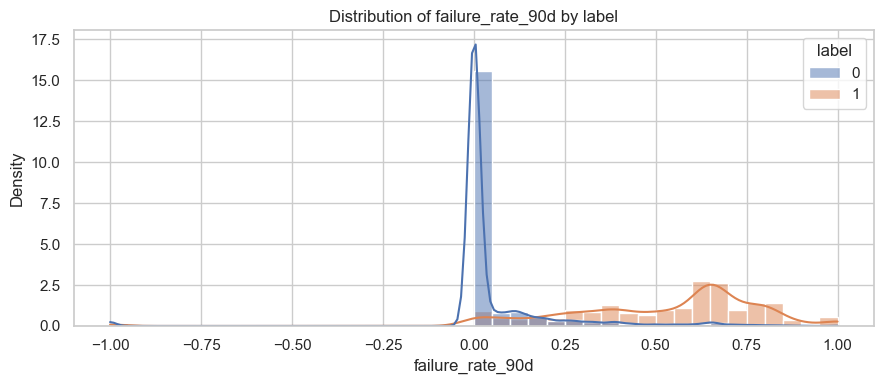

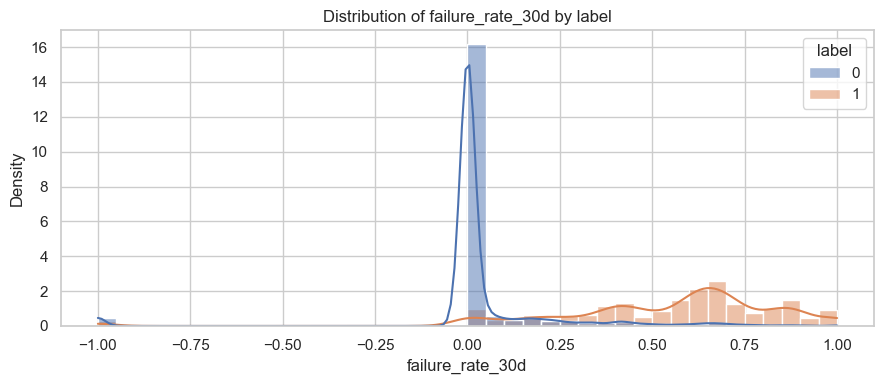

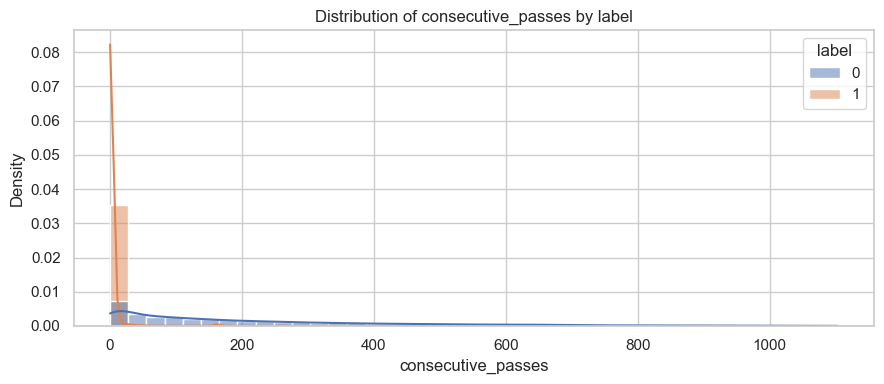

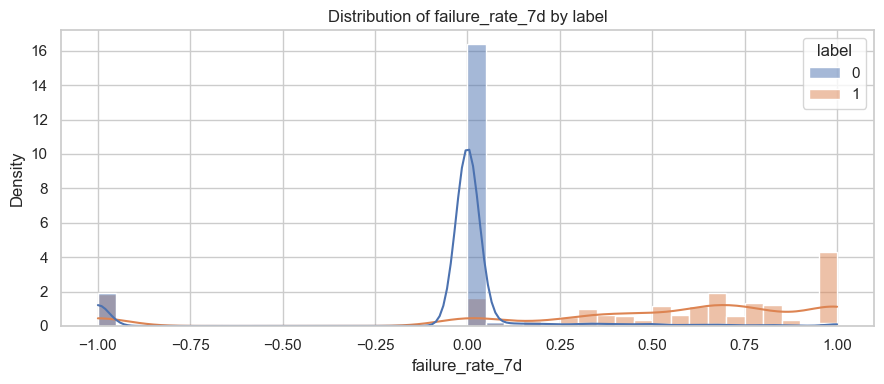

In [5]:
top5 = list(mi.head(5).index)
for feature in top5:
    plt.figure(figsize=(9, 4))
    sns.histplot(data=df, x=feature, hue='label', kde=True, stat='density', common_norm=False, bins=40)
    plt.title(f'Distribution of {feature} by label')
    plt.tight_layout()
    plt.show()

## 6. days_since_last_fail vs failure_rate_30d

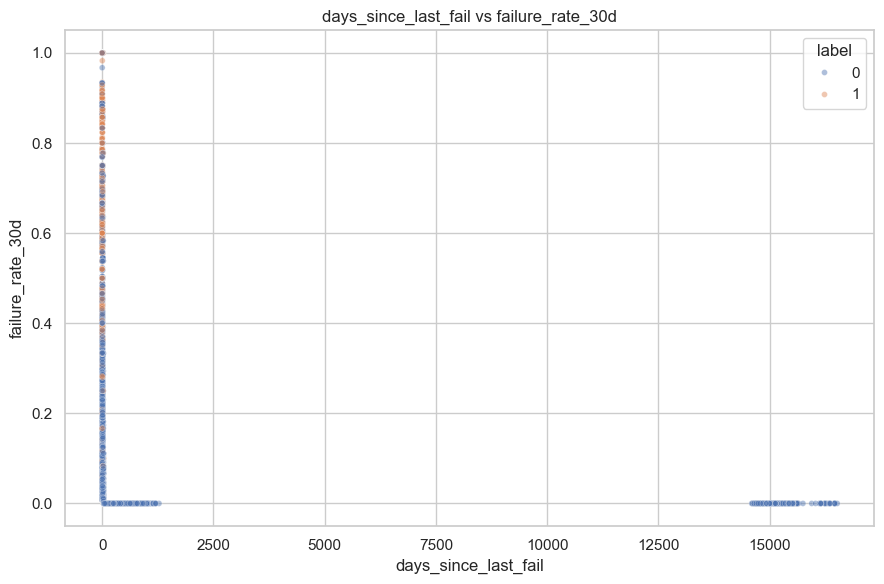

In [6]:
scatter_df = df[(df['days_since_last_fail'] != 999) & (df['failure_rate_30d'] != -1)].copy()
scatter_sample = scatter_df.sample(n=min(5000, len(scatter_df)), random_state=42)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=scatter_sample, x='days_since_last_fail', y='failure_rate_30d', hue='label', alpha=0.45, s=18)
plt.title('days_since_last_fail vs failure_rate_30d')
plt.tight_layout()
plt.show()

## Conclusion

The top 3 features by mutual information are `days_since_last_fail`, `failure_rate_90d`, and `failure_rate_30d`. This is consistent with regression-test-prioritization intuition: recent and rolling per-test failure history carries the strongest signal for whether a test will fail again. Correlation results also place `last_outcome` and the rolling failure rates at the top, which supports the same conclusion from a simpler linear view. No data leakage detected - all history features are computed from records strictly before `as_of_ts`; rows without `commit_sha` use `job_sequence` fallback and are tracked by `feature_source`.

`commit_meta_missing` rates are 30.42% for `adamfisk@LittleProxy`, 5.70% for `deeplearning4j@deeplearning4j`, 19.33% for `l0rdn1kk0n@wicket-bootstrap`, 0.10% for `neuland@jade4j`, and 12.91% for `thinkaurelius@titan`. `commit_diff_missing` is near-total because the local clones are blobless and line-count diffs would require lazy-fetching missing blobs; line-count churn columns are therefore retained with an explicit audit flag rather than treated as reliable signal in this snapshot.